This code simulates the stochastic model and plots the stochastic trajectory for $Z$ along the the deterministic solution

0.6109178744376779 0.6142128861863521
The maximum variation in XY1 in one Gillespie timestep is 3.743 %.
The maximum variation in XY2 in one Gillespie timestep is 0.068 %.


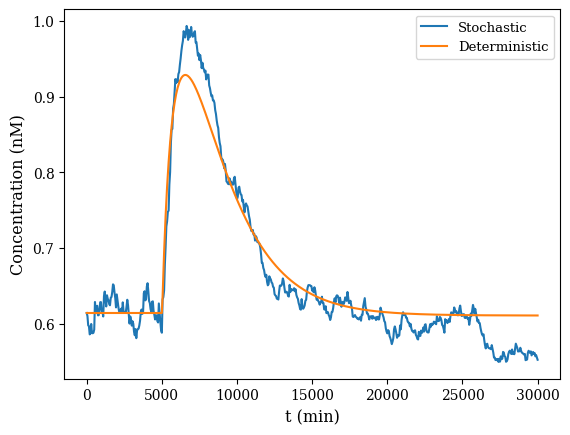

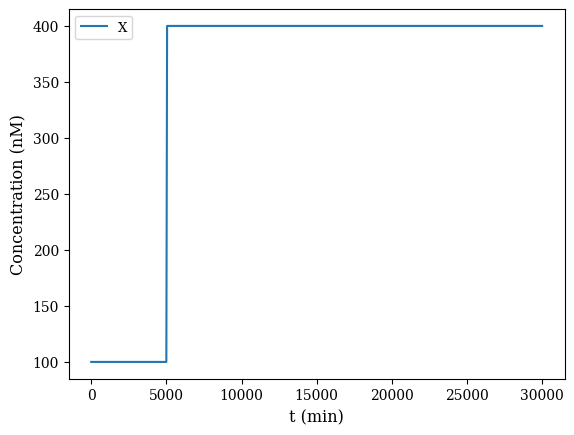

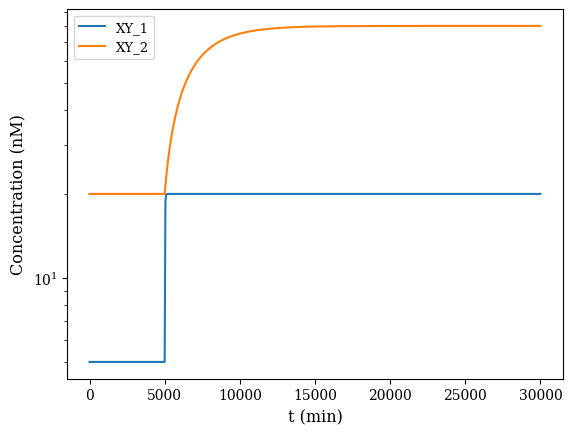

In [7]:
import numpy as np
import numba as nb
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# params
# beta1  = 3.0e-11;  alpha1 = 3.0e-2
# beta2  = 1e-12;    alpha2 = 2.0e-4
# beta3  = 4.1;     alpha3 = 4.1e-4
# K1     = 60;     K2     = 0.5
# k_off1 = 60;     k_off2 = 1
# k_on1 = 60; k_on2 = 60
# t_max  = 30000.0; t_step = 5000.0
# record_dt = 50.0; X0 = 10

alpha1 = 0.05
alpha2 = 0.0005

beta1  = 0.0025    # beta1/alpha1 = 0.05
beta2  = 0.0001    # beta2/alpha2 = 0.2

k_on1  = 0.06
k_off1 = 60.0      # K1 = 60

k_on2  = 60
k_off2 = 15      # K2 = 0.5

beta3  = 4.1;     alpha3 = 4.1e-4

t_max      = 30000.0
t_step     = 5000.0
record_dt  = 50.0
fold_change = 4
X0         = 100


@nb.njit
def calculate_XY(t, alpha, beta):
    XY_ss  = beta / alpha * X0
    X_high = fold_change * X0
    if t < t_step:
        return XY_ss
    else:
        return beta/alpha * X_high + (XY_ss - beta/alpha * X_high) * np.exp(-alpha * (t - t_step))

@nb.njit
def calc_Z(Z0, dt, state):
    ss = (beta3 / alpha3) if state == 2 else 0.0
    return ss + (Z0 - ss) * np.exp(-alpha3 * dt)

@nb.njit
def allowed_moves(state, XY1, XY2, k_on1_val, k_off1_val, k_on2_val, k_off2_val):
    moves = np.empty(2, dtype=np.int64)
    rates = np.empty(2, dtype=np.float64)
    if state == 0:
        moves[0] = 2; rates[0] = XY1*k_on1_val
        moves[1] = 1; rates[1] = XY2*k_on2_val
    elif state == 1:
        moves[0] = 3; rates[0] = XY1*k_on1_val
        moves[1] = 0; rates[1] = k_off2_val
    elif state == 2:
        moves[0] = 0; rates[0] = k_off1_val
        moves[1] = 3; rates[1] = XY2*k_on2_val
    else:
        moves[0] = 1; rates[0] = k_off1_val
        moves[1] = 2; rates[1] = k_off2_val
    return moves, rates

def deterministic_solution(t_arr):
    def P_active(t):
        XY1 = calculate_XY(t, alpha1, beta1)
        XY2 = calculate_XY(t, alpha2, beta2)
        P1  = (XY1) / (XY1 + k_off1 / k_on1)   # P(WRE bound)
        PN2 = k_off2/k_on2 / (k_off2/k_on2 + XY2)           # P(NRE unbound)
        return P1 * PN2

    def dZdt(t, Z):
        return [beta3 * P_active(t) - alpha3 * Z[0]]

    Z0  = (beta3 / alpha3) * P_active(t_arr[0])
    sol = solve_ivp(dZdt, [t_arr[0], t_arr[-1]], [Z0],
                    t_eval=t_arr, method='RK45', rtol=1e-8, atol=1e-10)
    return sol.y[0]

@nb.njit
def run_simulation(Z_arr, k_on1_val, k_off1_val, k_on2_val, k_off2_val):
    XY1_init = beta1 / alpha1 * X0
    XY2_init = beta2 / alpha2 * X0
    P_active_init = (XY1_init / (k_off1_val/k_on1_val + XY1_init)) * (1.0 / (1 + XY2_init*k_on2_val/k_off2_val))
    Z = (beta3 / alpha3) * P_active_init

    state   = 0
    t       = 0.0
    t_track = 0.0
    ind     = 1
    Z_arr[0] = Z

    delta_XY1_max = 0
    delta_XY2_max = 0

    while t < t_max:
        XY1 = calculate_XY(t, alpha1, beta1)
        XY2 = calculate_XY(t, alpha2, beta2)

        moves, rates = allowed_moves(state, XY1, XY2, k_on1_val, k_off1_val, k_on2_val, k_off2_val)
        R = np.sum(rates)

        u = np.random.uniform()
        dt_jump = 1.0 / R * np.log(1.0 / u)

        delta_XY1 = (calculate_XY(t+dt_jump, alpha1, beta1)-XY1)/XY1
        delta_XY2 = (calculate_XY(t+dt_jump, alpha2, beta2)-XY2)/XY2
        if delta_XY1 > delta_XY1_max:
            delta_XY1_max = delta_XY1
        if delta_XY2 > delta_XY2_max:
            delta_XY2_max = delta_XY2

        while ind * record_dt < t + dt_jump and ind * record_dt <= t_max:
            new_Z = calc_Z(Z, ind * record_dt - t_track, state)
            Z_arr[ind] = new_Z
            t_track = ind * record_dt
            Z = new_Z
            ind += 1

        Z = calc_Z(Z, t + dt_jump - t_track, state)
        t += dt_jump
        t_track = t

        u2    = np.random.uniform()
        state = moves[0] if u2 < rates[0] / R else moves[1]

    return Z_arr, delta_XY1_max, delta_XY2_max


t_arr = np.arange(0, t_max + record_dt, record_dt)
Z_arr = np.zeros_like(t_arr)

Z_arr, delta_XY1_max, delta_XY2_max = run_simulation(Z_arr, k_on1, k_off1, k_on2, k_off2)
Z_arr_det = deterministic_solution(t_arr)

print(Z_arr_det[-1], Z_arr_det[0])

print(f'The maximum variation in XY1 in one Gillespie timestep is {round(delta_XY1_max*100, 3)} %.')
print(f'The maximum variation in XY2 in one Gillespie timestep is {round(delta_XY2_max*100, 3)} %.')

plt.plot(t_arr, Z_arr, label='Stochastic')
plt.plot(t_arr, Z_arr_det, label='Deterministic')
plt.xlabel('t (min)')
plt.legend()
plt.ylabel('Concentration (nM)')
plt.show()

# plt.plot(t_arr, Z_arr, label='Stochastic')
# plt.plot(t_arr, Z_arr_det, label='Z')
# plt.xlabel('t (min)')
# plt.legend()
# plt.ylim(0.03, 0.07)
# plt.ylabel('Concentration (nM)')
# plt.show()

XY1 = np.array([calculate_XY(t, alpha1, beta1) for t in t_arr])
XY2 = np.array([calculate_XY(t, alpha2, beta2) for t in t_arr])

plt.figure()
plt.plot(t_arr, np.ones_like(t_arr)*X0+(t_arr>t_step)*(fold_change-1)*X0, label="X")
# plt.plot(t_arr, XY2, label="XY_2")
# plt.yscale()
plt.legend()
# plt.ylim(0,500)
plt.xlabel('t (min)')
plt.ylabel('Concentration (nM)')
plt.show()

plt.figure()
plt.plot(t_arr, XY1, label="XY_1")
plt.plot(t_arr, XY2, label="XY_2")
# plt.ylim(2, 200)
plt.yscale('log')
plt.legend()
plt.xlabel('t (min)')
plt.ylabel('Concentration (nM)')
plt.show()

The following code runs the predicted steady state relRMSE for the output for a step input. Some of the system's parameters are adjusted to see if the 1/x prediction is accurate.

[1/6] sweeping k_on1  (8 values)
    k_on1=     0.002  x=      6.9  pred= 0.3807  meas= 0.3715 +/- 0.0375
    k_on1=  0.004092  x=     14.1  pred= 0.2662  meas= 0.3008 +/- 0.0399
    k_on1=  0.008371  x=     28.8  pred= 0.1862  meas= 0.1716 +/- 0.0227
    k_on1=   0.01713  x=     58.9  pred= 0.1303  meas= 0.1391 +/- 0.00809
    k_on1=   0.03504  x=      120  pred=0.09127  meas=0.09357 +/- 0.0159
    k_on1=   0.07168  x=      244  pred=0.06405  meas=0.06134 +/- 0.00217
    k_on1=    0.1466  x=      491  pred=0.04513  meas=0.04506 +/- 0.0051
    k_on1=       0.3  x=      974  pred=0.03204  meas= 0.0306 +/- 0.00619
[2/6] sweeping k_off1  (6 values)
    k_off1=         5  x=      203  pred=0.07018  meas= 0.0712 +/- 0.00866
    k_off1=     8.219  x=      156  pred=0.07995  meas=0.07778 +/- 0.00607
    k_off1=     13.51  x=      114  pred=0.09361  meas=0.09139 +/- 0.00686
    k_off1=     22.21  x=     79.2  pred= 0.1123  meas=0.09825 +/- 0.00666
    k_off1=      36.5  x=     52.9  pred= 0.13

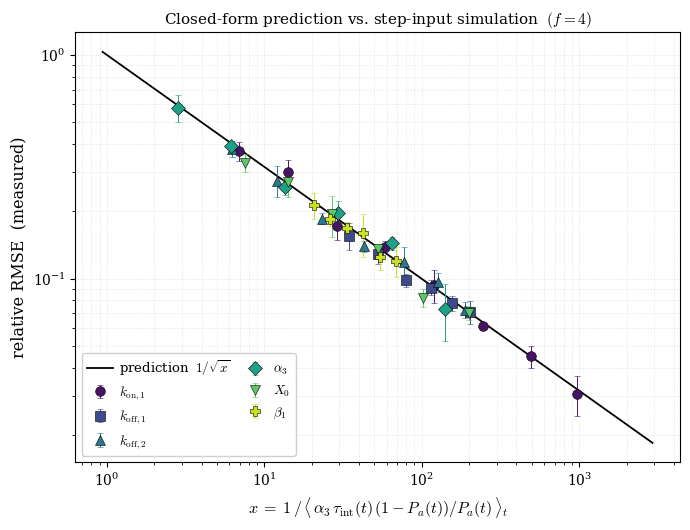

In [ ]:
"""
Test of the closed-form relRMSE prediction WITH the fold-change step input.

The thesis derives in steady state
    relRMSE^2  =  alpha3 * tau_int * (1 - <Pa>) / <Pa>

We plot measured relRMSE against  x_eff = 1 / relRMSE_pred^2  so the
prediction line is still  1/sqrt(x).
"""

import numpy as np
import numba as nb
import matplotlib.pyplot as plt
import matplotlib as mpl
from scipy.integrate import solve_ivp
from scipy.interpolate import interp1d
import time

# ---------------------------------------------------------------------------
# Baseline parameters (matching the thesis script)
# ---------------------------------------------------------------------------
BASE = dict(
    alpha1=0.05,     beta1=0.0025,    # XY1 SS = 5 nM (pre), 20 nM (post, f=4)
    alpha2=0.0005,   beta2=0.0001,    # XY2 SS = 20 nM (pre), 80 nM (post)
    k_on1=0.01,      k_off1=60.0,
    k_on2=60.0,      k_off2=6.0,
    beta3=4.1,       alpha3=4.1e-4,
    X0=100.0,
)

FOLD_CHANGE = 4
T_STEP      = 15000.0   # late step => 5/alpha3 of pre-step burn-in
T_MAX       = 1.0e5
T_BURN      = 5000.0    # discard t < T_BURN from measurement
RECORD_DT   = 50.0


# ---------------------------------------------------------------------------
# Time-varying input
# ---------------------------------------------------------------------------
@nb.njit(cache=True, inline='always')
def calc_XY(t, alpha, beta, X0, fold_change, t_step):
    XY_ss   = beta/alpha * X0
    XY_high = beta/alpha * fold_change * X0
    if t < t_step:
        return XY_ss
    return XY_high + (XY_ss - XY_high) * np.exp(-alpha * (t - t_step))


def calc_XY_np(t_arr, alpha, beta, X0, fold_change, t_step):
    XY_ss   = beta/alpha * X0
    XY_high = beta/alpha * fold_change * X0
    dt      = np.maximum(t_arr - t_step, 0.0)
    return np.where(t_arr < t_step, XY_ss,
                    XY_high + (XY_ss - XY_high)*np.exp(-alpha*dt))


# ---------------------------------------------------------------------------
# Gillespie + hybrid Z, step input
# ---------------------------------------------------------------------------
@nb.njit(cache=True)
def simulate_step(alpha1, beta1, alpha2, beta2, k_on1, k_off1, k_on2, k_off2,
                  beta3, alpha3, X0, fold_change,
                  t_step, t_max, record_dt, seed):
    np.random.seed(seed)
    n_rec = int(t_max / record_dt) + 1
    Z_arr = np.empty(n_rec)

    # initialise Z at the pre-step deterministic SS
    XY1 = beta1/alpha1 * X0
    XY2 = beta2/alpha2 * X0
    K1  = k_off1/k_on1
    K2  = k_off2/k_on2
    p1  = XY1/(XY1 + K1)
    p2  = XY2/(XY2 + K2)
    Z = beta3 * p1*(1 - p2) / alpha3
    Z_arr[0] = Z

    state = 0
    t = 0.0
    t_track = 0.0
    ind = 1

    while t < t_max and ind < n_rec:
        XY1 = calc_XY(t, alpha1, beta1, X0, fold_change, t_step)
        XY2 = calc_XY(t, alpha2, beta2, X0, fold_change, t_step)

        if state == 0:
            r_a = XY1*k_on1;  next_a = 2
            r_b = XY2*k_on2;  next_b = 1
        elif state == 1:
            r_a = XY1*k_on1;  next_a = 3
            r_b = k_off2;     next_b = 0
        elif state == 2:
            r_a = k_off1;     next_a = 0
            r_b = XY2*k_on2;  next_b = 3
        else:
            r_a = k_off1;     next_a = 1
            r_b = k_off2;     next_b = 2

        R = r_a + r_b
        dt_jump = -np.log(np.random.uniform()) / R

        ss = (beta3/alpha3) if state == 2 else 0.0
        while ind*record_dt < t + dt_jump and ind < n_rec:
            dt_ = ind*record_dt - t_track
            Z = ss + (Z - ss)*np.exp(-alpha3*dt_)
            Z_arr[ind] = Z
            t_track = ind*record_dt
            ind += 1
        Z = ss + (Z - ss)*np.exp(-alpha3*(t + dt_jump - t_track))
        t += dt_jump
        t_track = t

        if np.random.uniform() < r_a/R:
            state = next_a
        else:
            state = next_b

    while ind < n_rec:
        Z_arr[ind] = Z
        ind += 1
    return Z_arr


# ---------------------------------------------------------------------------
# Deterministic ODE solution for Z(t) and time-averaged prediction
# ---------------------------------------------------------------------------
def _local_pred(params, t_arr, t_step, fold_change):
    XY1 = calc_XY_np(t_arr, params['alpha1'], params['beta1'],
                     params['X0'], fold_change, t_step)
    XY2 = calc_XY_np(t_arr, params['alpha2'], params['beta2'],
                     params['X0'], fold_change, t_step)
    K1 = params['k_off1']/params['k_on1']
    K2 = params['k_off2']/params['k_on2']
    p1 = XY1/(XY1 + K1)
    p2 = XY2/(XY2 + K2)
    r1 = XY1*params['k_on1'] + params['k_off1']
    r2 = XY2*params['k_on2'] + params['k_off2']
    Pa = p1*(1 - p2)
    integral = (p1**2 * p2*(1 - p2)/r2
                + (1 - p2)**2 * p1*(1 - p1)/r1
                + p1*(1 - p1)*p2*(1 - p2)/(r1 + r2))
    tau_int = integral / (Pa*(1 - Pa))
    rel_var = params['alpha3'] * tau_int * (1 - Pa) / Pa  # local relRMSE^2
    return Pa, tau_int, rel_var


def deterministic_Z(params, t_arr, t_step, fold_change):
    Pa, _, _ = _local_pred(params, t_arr, t_step, fold_change)
    Pa_func = interp1d(t_arr, Pa, kind='linear', fill_value='extrapolate',
                       assume_sorted=True)

    def dZdt(t, Z):
        return params['beta3']*Pa_func(t) - params['alpha3']*Z[0]

    Z0 = params['beta3']*Pa[0]/params['alpha3']
    sol = solve_ivp(dZdt, [t_arr[0], t_arr[-1]], [Z0], t_eval=t_arr,
                    method='RK45', rtol=1e-8, atol=1e-10, max_step=200.0)
    return sol.y[0]


def predict_step(params, t_arr, burn_idx, t_step, fold_change):
    # Use a finer grid for the integral so the brief peak in Pa is resolved
    t_fine = np.linspace(t_arr[burn_idx], t_arr[-1], 8001)
    _, _, rv = _local_pred(params, t_fine, t_step, fold_change)
    avg_rv = np.trapz(rv, t_fine) / (t_fine[-1] - t_fine[0])
    return 1.0/avg_rv, np.sqrt(avg_rv)


def measure_step(params, t_arr, Z_det, burn_idx, t_step, fold_change,
                 n_rep=3, seed0=0):
    rec_dt = t_arr[1] - t_arr[0]
    rmses = np.empty(n_rep)
    for r in range(n_rep):
        Z = simulate_step(params['alpha1'], params['beta1'],
                          params['alpha2'], params['beta2'],
                          params['k_on1'],  params['k_off1'],
                          params['k_on2'],  params['k_off2'],
                          params['beta3'],  params['alpha3'],
                          params['X0'],     fold_change,
                          t_step, t_arr[-1], rec_dt, seed0 + r)
        n = min(len(Z), len(Z_det))
        resid = (Z[burn_idx:n] - Z_det[burn_idx:n]) / Z_det[burn_idx:n]
        rmses[r] = np.sqrt(np.mean(resid**2))
    return rmses.mean(), (rmses.std(ddof=1) if n_rep > 1 else 0.0)


# ---------------------------------------------------------------------------
# Sweeps - picked to cover a wide range of x_eff and not crowd around a point
#   * beta2 dropped: XY2 deep in saturation, no effect on x
#   * k_on2 dropped: same reason, narrow x range
#   * k_off2 kept: still varies K2 = k_off2/k_on2 significantly
# ---------------------------------------------------------------------------
SWEEPS = [
    ('k_on1',  r'$k_{\mathrm{on},1}$',  np.geomspace(2e-3, 3e-1, 8)),
    ('k_off1', r'$k_{\mathrm{off},1}$', np.geomspace(5.0,  60.0, 6)),
    ('k_off2', r'$k_{\mathrm{off},2}$', np.geomspace(1.0,  60.0, 7)),
    ('alpha3', r'$\alpha_3$',           np.geomspace(1e-4, 5e-3, 6)),
    ('X0',     r'$X_0$',                np.geomspace(20.0, 600.0, 6)),
    ('beta1',  r'$\beta_1$',            np.geomspace(1.5e-3, 5e-3, 6)),
]


def run_all(n_rep=3, verbose=True):
    t_arr = np.arange(0, T_MAX + RECORD_DT, RECORD_DT)
    burn_idx = int(T_BURN / RECORD_DT)
    results  = {}
    t0 = time.time()
    for i, (name, label, values) in enumerate(SWEEPS):
        if verbose:
            print(f'[{i+1}/{len(SWEEPS)}] sweeping {name}  ({len(values)} values)')
        rows = []
        for j, v in enumerate(values):
            p = BASE.copy()
            p[name] = v
            Z_det = deterministic_Z(p, t_arr, T_STEP, FOLD_CHANGE)
            x_eff, pred = predict_step(p, t_arr, burn_idx, T_STEP, FOLD_CHANGE)
            seed_base = (abs(hash(name)) & 0xFFFFFF) + j*100 + 1
            meas, std = measure_step(p, t_arr, Z_det, burn_idx,
                                     T_STEP, FOLD_CHANGE,
                                     n_rep=n_rep, seed0=seed_base)
            rows.append((v, x_eff, pred, meas, std))
            if verbose:
                print(f'    {name}={v:10.4g}  x={x_eff:9.3g}  '
                      f'pred={pred:7.4g}  meas={meas:7.4g} +/- {std:6.3g}')
        results[name] = (label, np.array(rows))
    if verbose:
        print(f'total wall time: {time.time()-t0:.1f} s')
    return results


# ---------------------------------------------------------------------------
# Plot
# ---------------------------------------------------------------------------
def plot_results(results, save_stem='step_rmse_collapse'):
    mpl.rcParams.update({
        'font.family': 'serif',
        'mathtext.fontset': 'cm',
        'axes.labelsize': 11.5,
        'axes.titlesize': 11,
        'legend.fontsize': 9.5,
        'xtick.labelsize': 10,
        'ytick.labelsize': 10,
        'axes.linewidth': 0.8,
    })

    fig, ax = plt.subplots(figsize=(7.0, 5.4))

    all_x = np.concatenate([arr[:, 1] for _, arr in results.values()])
    x_th  = np.geomspace(all_x.min()/3, all_x.max()*3, 300)
    ax.plot(x_th, 1.0/np.sqrt(x_th), color='black', lw=1.3, zorder=2,
            label=r'prediction $\;1/\sqrt{x}$')

    cmap    = plt.get_cmap('viridis')(np.linspace(0.05, 0.92, len(results)))
    markers = ['o', 's', '^', 'D', 'v', 'P', 'X', '<', '>', '*', 'h']

    for (name, (label, arr)), color, mk in zip(results.items(), cmap, markers):
        xs, ms, es = arr[:, 1], arr[:, 3], arr[:, 4]
        ax.errorbar(xs, ms, yerr=es, fmt=mk, color=color, ms=7, mec='black',
                    mew=0.4, capsize=2.5, lw=0.7, label=label, zorder=4)

    ax.set_xscale('log'); ax.set_yscale('log')
    ax.set_ylabel('relative RMSE  (measured)')
    ax.set_xlabel(r'$x\;=\;'
                  r'1\,/\,\langle\,\alpha_3\,\tau_{\mathrm{int}}(t)\,'
                  r'(1-P_a(t))/P_a(t)\,\rangle_t$')
    ax.set_title(r'Closed-form prediction vs. step-input simulation  '
                 rf'$(f={FOLD_CHANGE})$', fontsize=11)
    ax.grid(True, which='both', ls=':', lw=0.4, alpha=0.6)
    ax.legend(ncol=2, loc='lower left', framealpha=0.93,
              handletextpad=0.4, columnspacing=0.9, borderpad=0.4)

    fig.tight_layout()
    fig.savefig(f'{save_stem}.png', dpi=200, bbox_inches='tight')
    fig.savefig(f'{save_stem}.pdf', bbox_inches='tight')
    return fig


if __name__ == '__main__':
    # warmup so the JIT cost doesn't pollute the first timing
    simulate_step(0.05, 0.0025, 0.0005, 0.0001, 0.01, 60.0, 60.0, 6.0,
                  4.1, 4.1e-4, 100.0, 4, 15000.0, 1000.0, 50.0, 0)

    results = run_all(n_rep=3, verbose=True)
    plot_results(results, save_stem='./figures/step_rmse_collapse')

The following code sumulates many trajectories, and plots the average trajectory +- one std along with the deterministic trajectory. Also, one noisy trajectory is plotted.

X0 =   10.0 nM : 1000 runs in   3.1 s (3.1 ms / run)
X0 =  100.0 nM : 1000 runs in   3.5 s (3.5 ms / run)
X0 = 1000.0 nM : 1000 runs in   3.5 s (3.5 ms / run)


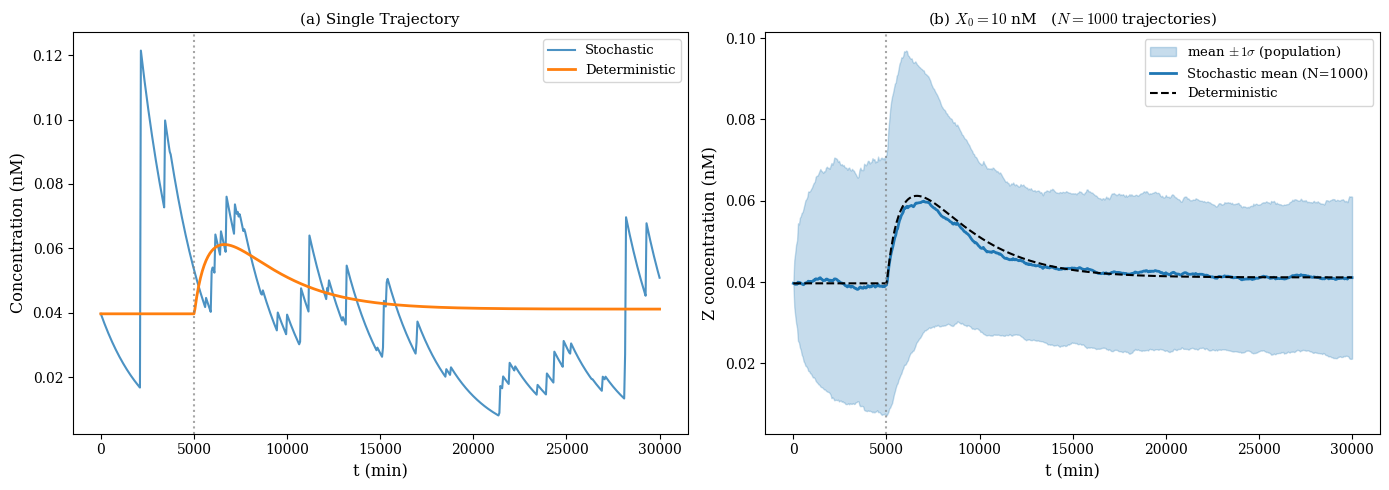

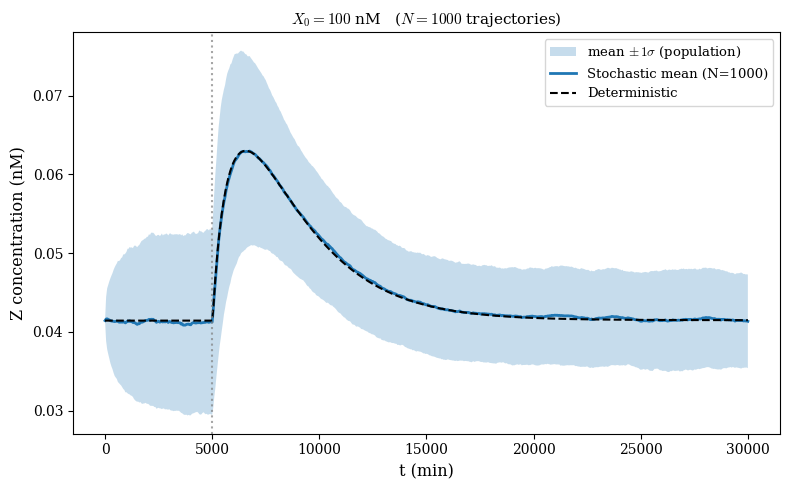

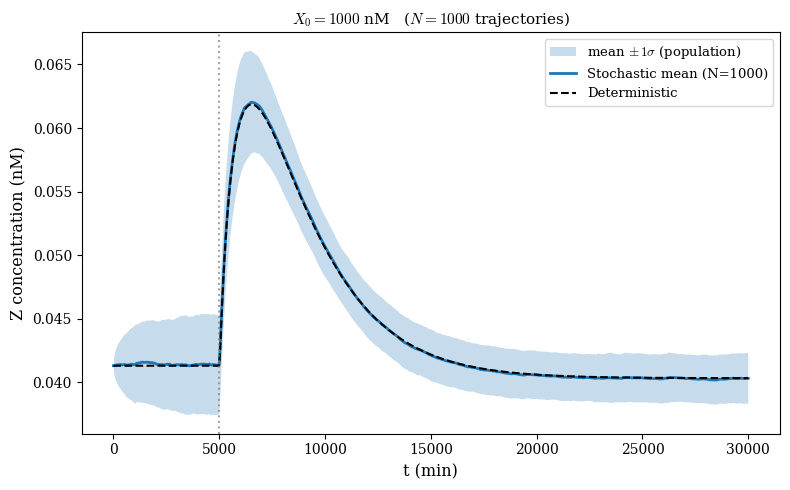

In [2]:
import numpy as np
import numba as nb
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
import time

# ---------------- parameters ----------------
alpha1 = 0.05
alpha2 = 0.0005
beta1  = 0.0025
beta2  = 0.0001

k_on1  = 0.01
k_off1 = 60.0
k_on2  = 60.0
k_off2 = 6.0

beta3  = 4.1
alpha3 = 4.1e-4

t_max       = 30000.0
t_step      = 5000.0
record_dt   = 50.0
fold_change = 4

N_runs    = 1000
X0_values = (10.0, 100.0, 1000.0)

# ---------------- core kernels ----------------
@nb.njit(inline='always', cache=True, fastmath=True)
def calculate_XY(t, alpha, beta, X0):
    XY_ss = beta / alpha * X0
    if t < t_step:
        return XY_ss
    X_high = fold_change * X0
    target = beta / alpha * X_high
    return target + (XY_ss - target) * np.exp(-alpha * (t - t_step))

@nb.njit(inline='always', cache=True, fastmath=True)
def calc_Z(Z0, dt, state):
    ss = (beta3 / alpha3) if state == 2 else 0.0
    return ss + (Z0 - ss) * np.exp(-alpha3 * dt)

@nb.njit(cache=True, fastmath=True)
def run_single(Z_arr, X0):
    """One Gillespie trajectory, written into Z_arr (length n_rec)."""
    n_rec = Z_arr.shape[0]

    # initial steady state
    XY1_init = beta1 / alpha1 * X0
    XY2_init = beta2 / alpha2 * X0
    P_active_init = (XY1_init / (k_off1 / k_on1 + XY1_init)) \
                  * (1.0 / (1.0 + XY2_init * k_on2 / k_off2))
    Z = (beta3 / alpha3) * P_active_init

    state   = 0
    t       = 0.0
    t_track = 0.0
    ind     = 1
    Z_arr[0] = Z

    while t < t_max:
        XY1 = calculate_XY(t, alpha1, beta1, X0)
        XY2 = calculate_XY(t, alpha2, beta2, X0)

        if state == 0:
            m0, r0 = 2, XY1 * k_on1
            m1, r1 = 1, XY2 * k_on2
        elif state == 1:
            m0, r0 = 3, XY1 * k_on1
            m1, r1 = 0, k_off2
        elif state == 2:
            m0, r0 = 0, k_off1
            m1, r1 = 3, XY2 * k_on2
        else:
            m0, r0 = 1, k_off1
            m1, r1 = 2, k_off2

        R = r0 + r1
        u = np.random.uniform()
        dt_jump = -np.log(u) / R

        while ind < n_rec and ind * record_dt < t + dt_jump and ind * record_dt <= t_max:
            new_Z = calc_Z(Z, ind * record_dt - t_track, state)
            Z_arr[ind] = new_Z
            t_track = ind * record_dt
            Z = new_Z
            ind += 1

        Z = calc_Z(Z, t + dt_jump - t_track, state)
        t += dt_jump
        t_track = t

        u2 = np.random.uniform()
        state = m0 if u2 < r0 / R else m1

@nb.njit(parallel=True, cache=True)
def run_many(n_runs, n_rec, X0):
    """Run n_runs trajectories in parallel; returns (n_runs, n_rec) array."""
    all_Z = np.empty((n_runs, n_rec))
    for i in nb.prange(n_runs):
        run_single(all_Z[i], X0)
    return all_Z

# ---------------- deterministic reference ----------------
def deterministic_solution(t_arr, X0):
    def P_active(t):
        XY1 = calculate_XY(t, alpha1, beta1, X0)
        XY2 = calculate_XY(t, alpha2, beta2, X0)
        P1  = XY1 / (XY1 + k_off1 / k_on1)
        PN2 = (k_off2 / k_on2) / (k_off2 / k_on2 + XY2)
        return P1 * PN2

    def dZdt(t, Z):
        return [beta3 * P_active(t) - alpha3 * Z[0]]

    Z0  = (beta3 / alpha3) * P_active(t_arr[0])
    sol = solve_ivp(dZdt, [t_arr[0], t_arr[-1]], [Z0],
                    t_eval=t_arr, method='RK45', rtol=1e-8, atol=1e-10)
    return sol.y[0]

# ---------------- run sweep ----------------
t_arr = np.arange(0, t_max + record_dt, record_dt)
n_rec = t_arr.size

_ = run_many(2, n_rec, 10.0)

results = {}
for X0 in X0_values:
    t0 = time.perf_counter()
    Z_all = run_many(N_runs, n_rec, X0)
    Z_det = deterministic_solution(t_arr, X0)
    dt = time.perf_counter() - t0
    print(f"X0 = {X0:>6} nM : {N_runs} runs in {dt:5.1f} s "
          f"({dt / N_runs * 1000:.1f} ms / run)")
    results[X0] = (Z_all, Z_det)

# ---------------- plot ----------------
for X0 in X0_values:
    Z_all, Z_det = results[X0]
    mean = Z_all.mean(axis=0)
    std  = Z_all.std(axis=0)

    if np.isclose(X0, 10.0):
        # Create a side-by-side layout (1 row, 2 columns) specifically for X0 = 10
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
        
        # --- Left Panel: Single Stochastic Trajectory vs Deterministic ---
        single_trajectory = Z_all[0]  # Grab the very first trajectory from our data
        ax1.plot(t_arr, single_trajectory, color='C0', alpha=0.8, label='Stochastic')
        ax1.plot(t_arr, Z_det, color='C1', lw=2, label='Deterministic')
        ax1.axvline(t_step, color='grey', ls=':', alpha=0.7)
        ax1.set_xlabel('t (min)')
        ax1.set_ylabel('Concentration (nM)')
        ax1.set_title('(a) Single Trajectory')
        ax1.legend(loc='best')
        
        # --- Right Panel: Mean & Population Variance ---
        ax2.fill_between(t_arr, mean - std, mean + std, color='C0', alpha=0.25, 
                         label=r'mean $\pm\,1\sigma$ (population)')
        ax2.plot(t_arr, mean, color='C0', lw=2, label=f'Stochastic mean (N={N_runs})')
        ax2.plot(t_arr, Z_det, lw=1.5, ls='--', color='k', label='Deterministic')
        ax2.axvline(t_step, color='grey', ls=':', alpha=0.7)
        ax2.set_xlabel('t (min)')
        ax2.set_ylabel('Z concentration (nM)')
        ax2.set_title(f'(b) $X_0 = {X0:g}$ nM   ($N={N_runs}$ trajectories)')
        ax2.legend(loc='best')
        
        fig.tight_layout()
        
        # Save the combined side-by-side figure
        fig.savefig(f'./figures/trajectory_combined_X0_{int(X0)}.png', dpi=300)
        
    else:
        # Keep the original single-plot structure for X0 = 100 and X0 = 1000
        fig, ax = plt.subplots(figsize=(8, 5))
        ax.fill_between(t_arr, mean - std, mean + std, alpha=0.25, 
                        label=r'mean $\pm\,1\sigma$ (population)')
        ax.plot(t_arr, mean,  lw=2, label=f'Stochastic mean (N={N_runs})')
        ax.plot(t_arr, Z_det, lw=1.5, ls='--', color='k', label='Deterministic')
        
        ax.axvline(t_step, color='grey', ls=':', alpha=0.7)
        ax.set_xlabel('t (min)')
        ax.set_ylabel('Z concentration (nM)')
        ax.set_title(f'$X_0 = {X0:g}$ nM   ($N={N_runs}$ trajectories)')
        ax.legend(loc='best')
        
        fig.tight_layout()

plt.show()

The following code tries to locate the FCD-compatible regime across the ($XY_1/K_1$,$XY_2/K_2$) regime. The results are in good agreement with the results of Goentoro et al.

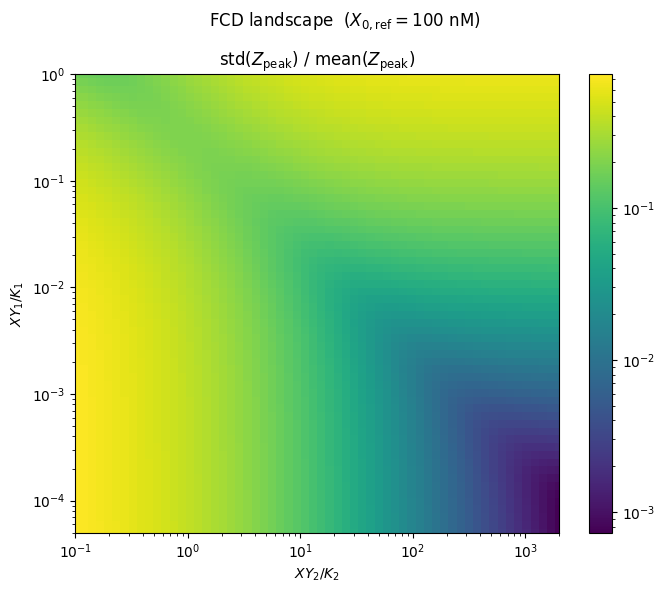

Figures saved to ./figures/


In [32]:
import os
import numpy as np
import numba as nb
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

os.makedirs('./figures', exist_ok=True)

# ---------------- Fixed parameters ----------------
alpha1 = 0.05
alpha2 = 0.0005
beta1  = 0.0025
beta2  = 0.0001

beta3  = 4.1
alpha3 = 4.1e-4

t_max       = 30000.0
t_step      = 5000.0
fold_change = 4

# Biological caps on the individual rates
K_ON1_MAX  = 60.0    # nM^-1 min^-1
K_OFF1_MAX = 60.0    # min^-1
K_ON2_MAX  = 60.0    # nM^-1 min^-1
K_OFF2_MAX = 60.0    # min^-1

# ================================================================
#  Grid specification — edit these to change the swept region.
#
#  Primary variables: rho1 = XY1/K1  (y-axis)
#                     rho2 = XY2/K2  (x-axis)
#
#  For each (rho1, rho2), K_i is derived at X0_ref:
#     K1 = XY1_ref / rho1,   K2 = XY2_ref / rho2
#
#  Then k_on,i and k_off,i are computed by optimal_rates():
#  their ratio equals K_i and they are as high as biologically
#  allowed (i.e. k_on is maximised subject to both caps).
# ================================================================
RHO1_LO, RHO1_HI = 5e-5, 1
RHO2_LO, RHO2_HI = 1e-1, 2e3

N_grid = 60
N_X0   = 1000

X0_ref  = np.sqrt(10.0 * 1000.0)       # geometric mean of X0 sweep = 100 nM
XY1_ref = beta1 / alpha1 * X0_ref      # = 5 nM
XY2_ref = beta2 / alpha2 * X0_ref      # = 20 nM

# ---------------- Rate optimisation ----------------
def optimal_rates(K_arr, k_on_max, k_off_max):
    """
    For each target dissociation constant K = k_off / k_on in K_arr,
    return the pair (k_on, k_off) that:
      - satisfies k_off / k_on = K exactly
      - maximises k_on (and hence the relaxation rate r = XY*k_on + k_off)
        subject to k_on <= k_on_max and k_off <= k_off_max.

    The optimal k_on is min(k_on_max, k_off_max / K):
      - when K < k_off_max/k_on_max: k_on hits its cap first
      - when K > k_off_max/k_on_max: k_off hits its cap, k_on = k_off_max/K
    """
    k_on  = np.minimum(k_on_max, k_off_max / K_arr)
    k_off = K_arr * k_on
    return k_on, k_off

# ---------------- Derived rate arrays ----------------
rho1_arr = np.logspace(np.log10(RHO1_LO), np.log10(RHO1_HI), N_grid)
rho2_arr = np.logspace(np.log10(RHO2_LO), np.log10(RHO2_HI), N_grid)

K1_arr = XY1_ref / rho1_arr
K2_arr = XY2_ref / rho2_arr

k_on1_arr,  k_off1_arr = optimal_rates(K1_arr, K_ON1_MAX, K_OFF1_MAX)
k_on2_arr,  k_off2_arr = optimal_rates(K2_arr, K_ON2_MAX, K_OFF2_MAX)

X0_samples = np.logspace(np.log10(10), np.log10(1000), N_X0)

# ---------------- Numba kernels ----------------
# peak_and_base now takes all four individual rates explicitly.
@nb.njit(cache=True, fastmath=True)
def peak_and_base(X0, k_on1, k_off1, k_on2, k_off2):
    K1 = k_off1 / k_on1
    K2 = k_off2 / k_on2

    XY1_0 = beta1 / alpha1 * X0
    XY2_0 = beta2 / alpha2 * X0
    P0     = (XY1_0 / (XY1_0 + K1)) * (K2 / (K2 + XY2_0))
    Z_base = beta3 / alpha3 * P0

    X_high = fold_change * X0
    XY1_T  = beta1 / alpha1 * X_high
    XY2_T  = beta2 / alpha2 * X_high

    u1 = XY1_0 - XY1_T
    u2 = XY2_0 - XY2_T

    dt      = 10.0
    n_steps = int((t_max - t_step) / dt)
    d1      = np.exp(-alpha1 * dt)
    d2      = np.exp(-alpha2 * dt)
    a       = alpha3
    e       = np.exp(-a * dt)
    I0      = (1.0 - e) / a
    I1      = (1.0 - (1.0 + a * dt) * e) / (a * a)
    c_b     = beta3 * (I0 - I1 / dt)
    c_a     = beta3 * (I1 / dt)

    XY1    = XY1_T + u1
    XY2    = XY2_T + u2
    Pa     = (XY1 / (XY1 + K1)) * (K2 / (K2 + XY2))
    Z      = Z_base
    Z_peak = Z_base

    for _ in range(n_steps):
        u1  *= d1
        u2  *= d2
        XY1  = XY1_T + u1
        XY2  = XY2_T + u2
        Pb   = (XY1 / (XY1 + K1)) * (K2 / (K2 + XY2))
        Z    = e * Z + c_a * Pa + c_b * Pb
        if Z > Z_peak:
            Z_peak = Z
        Pa = Pb

    return Z_peak, Z_base


@nb.njit(parallel=True, cache=True)
def scan_grid(k_on1_arr, k_off1_arr, k_on2_arr, k_off2_arr, X0_samples):
    n1 = k_on1_arr.shape[0]
    n2 = k_on2_arr.shape[0]
    nx = X0_samples.shape[0]

    mean_r = np.zeros((n1, n2))
    std_r  = np.zeros((n1, n2))

    for i in nb.prange(n1):
        peaks = np.empty(nx)
        for j in range(n2):
            for k in range(nx):
                Zp, _ = peak_and_base(X0_samples[k],
                                      k_on1_arr[i], k_off1_arr[i],
                                      k_on2_arr[j], k_off2_arr[j])
                peaks[k] = Zp

            m = 0.0
            for k in range(nx):
                m += peaks[k]
            m /= nx
            s = 0.0
            for k in range(nx):
                s += (peaks[k] - m) ** 2
            std_r[i, j]  = np.sqrt(s / nx)
            mean_r[i, j] = m

    return mean_r, std_r


# ---------------- Run ----------------
_ = scan_grid(np.array([0.01, 0.1]), np.array([0.01, 6.0]),
              np.array([1.0, 6.0]),  np.array([1.0, 6.0]),
              np.array([10.0, 100.0]))

mean_r, std_r = scan_grid(k_on1_arr, k_off1_arr, k_on2_arr, k_off2_arr, X0_samples)
cv_r = std_r / mean_r

# scan_grid[i, j] -> rho1_arr[i] (y), rho2_arr[j] (x): no transpose needed.

# ---------------- Plot 1: std(Z_peak) ----------------
# fig1, ax1 = plt.subplots(figsize=(7, 6))
# im1 = ax1.pcolormesh(rho2_arr, rho1_arr, std_r,
#                      norm=LogNorm(vmin=max(std_r.min(), 1e-6), vmax=std_r.max()),
#                      cmap='viridis', shading='auto')
# ax1.set_xscale('log')
# ax1.set_yscale('log')
# ax1.set_xlim(RHO2_LO, RHO2_HI)
# ax1.set_ylim(RHO1_LO, RHO1_HI)
# ax1.set_xlabel(r'$XY_2/K_2$')
# ax1.set_ylabel(r'$XY_1/K_1$')
# ax1.set_title(r'std$(Z_{\rm peak})$')
# plt.colorbar(im1, ax=ax1)
# fig1.suptitle(rf'FCD landscape  ($X_{{0,\mathrm{{ref}}}}={X0_ref:.0f}$ nM)')
# fig1.tight_layout()
# fig1.savefig('./figures/std_z_peak.png', dpi=300)
# plt.show()

# ---------------- Plot 2: CV(Z_peak) ----------------
fig2, ax2 = plt.subplots(figsize=(7, 6))
im2 = ax2.pcolormesh(rho2_arr, rho1_arr, cv_r,
                     norm=LogNorm(vmin=max(cv_r.min(), 1e-6), vmax=cv_r.max()),
                     cmap='viridis', shading='auto')
ax2.set_xscale('log')
ax2.set_yscale('log')
ax2.set_xlim(RHO2_LO, RHO2_HI)
ax2.set_ylim(RHO1_LO, RHO1_HI)
ax2.set_xlabel(r'$XY_2/K_2$')
ax2.set_ylabel(r'$XY_1/K_1$')
ax2.set_title(r'std$(Z_{\rm peak})$ / mean$(Z_{\rm peak})$')
plt.colorbar(im2, ax=ax2)
fig2.suptitle(rf'FCD landscape  ($X_{{0,\mathrm{{ref}}}}={X0_ref:.0f}$ nM)')
fig2.tight_layout()
fig2.savefig('./figures/cv_z_peak.png', dpi=300)
plt.show()

print("Figures saved to ./figures/")

This code sweeps across the ($XY_1/K_1$, $XY_2/K_2$) plane and simlates many trajectories for each pixel. The goal is to find an optimum in the tadeoff between FCD response and noise. Two information theoretic tests are performed. In the model, the option to add multiple sides is added.

Starting highly optimized structural execution loop...
10x10 parameter grid x 500 samples = 50,000 total trajectories
   Simulation Progress: 10.0 % complete ( 10 / 100  pixels)
   Simulation Progress: 20.0 % complete ( 20 / 100  pixels)
   Simulation Progress: 30.0 % complete ( 30 / 100  pixels)
   Simulation Progress: 40.0 % complete ( 40 / 100  pixels)
   Simulation Progress: 50.0 % complete ( 50 / 100  pixels)
   Simulation Progress: 60.0 % complete ( 60 / 100  pixels)
   Simulation Progress: 70.0 % complete ( 70 / 100  pixels)
   Simulation Progress: 80.0 % complete ( 80 / 100  pixels)
   Simulation Progress: 90.0 % complete ( 90 / 100  pixels)
   Simulation Progress: 100.0 % complete ( 100 / 100  pixels)
  Simulations executed in 116.26 min (139.52 ms/traj)

Starting Nonparametric Mutual Information analysis...
   MI evaluation executing on row 1/10...
   MI evaluation executing on row 3/10...
   MI evaluation executing on row 5/10...
   MI evaluation executing on row 7/10...
   

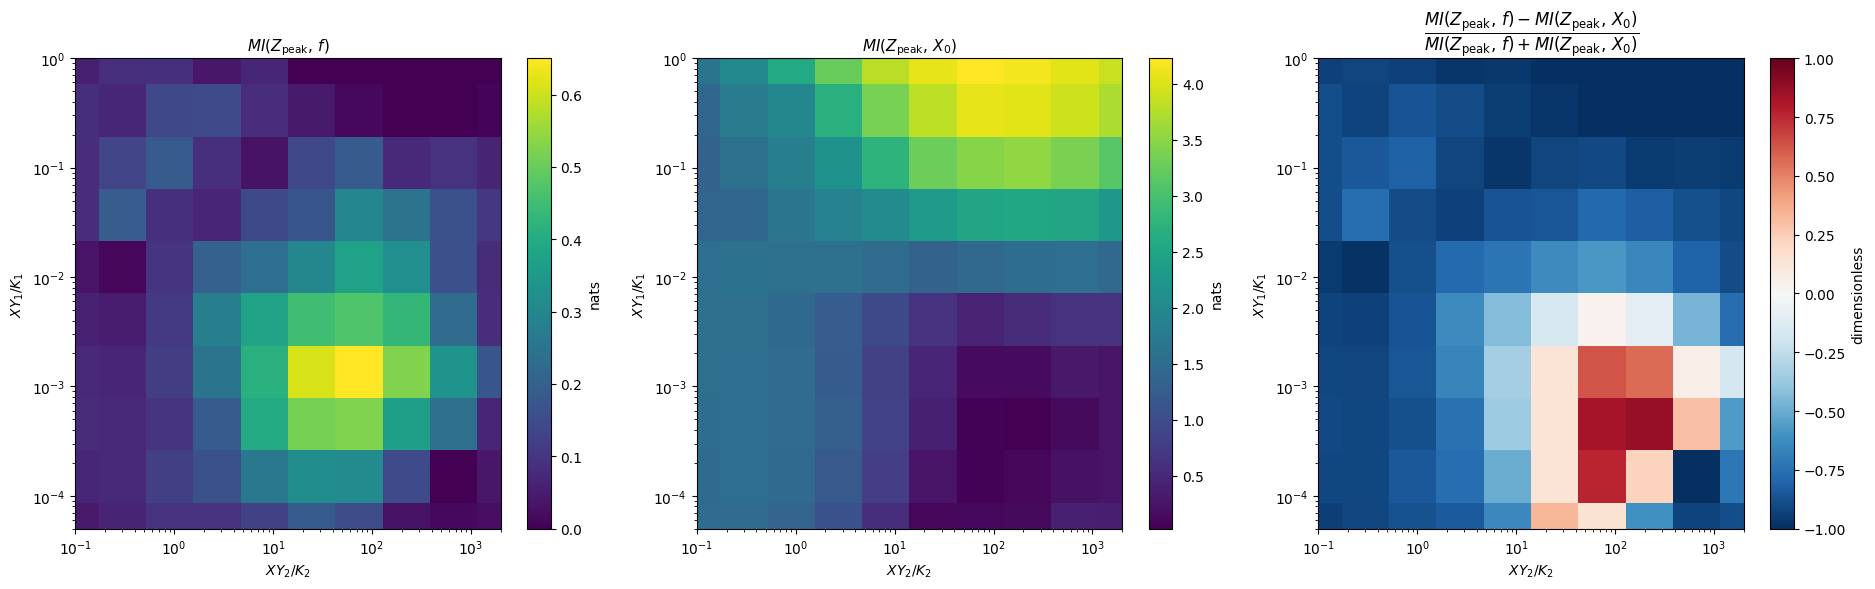

In [2]:
"""
Stochastic FCD multi-site landscape via a normalised mutual-information score,
computed entirely from Z_peak:
    score = (I(Z_peak; f) - I(Z_peak; X0)) / (I(Z_peak; f) + I(Z_peak; X0))
Hardcoded for OR-Activation / AND-Repression logic and highly optimized for speed.

Swept in terms of equilibrium occupancy ratios
    rho1 = XY1/K1  (activator site, y-axis)
    rho2 = XY2/K2  (repressor site, x-axis)
rather than raw rate constants. For each (rho1, rho2) grid point, the dissociation
constants K1, K2 are derived at a reference X0, and the individual k_on/k_off rates
are chosen via optimal_rates() to be as fast as biologically allowed while satisfying
k_off/k_on = K exactly -- the same approach used in the deterministic FCD landscape
script. This mirrors that script's grid spec since both share the same beta/alpha
kinetics, so the two landscapes are directly comparable.

Z_base and Z_end (the steady state before the perturbation and the state reached
at t_max) are still simulated and saved to the .npz for reference, but are not
used in the MI analysis below -- only Z_peak is used, for both MI terms.
"""

import os
import numpy as np
import numba as nb
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
from sklearn.feature_selection import mutual_info_regression
from time import perf_counter

# ---------------- Fixed Parameters ----------------
beta1  = 0.0025
alpha1 = 0.05
beta2  = 0.0001
alpha2 = 0.0005
beta3  = 4.1
alpha3 = 4.1e-4

t_max  = 25000.0
t_step = 5000.0

# ---------------- Biological caps on individual rates ----------------
K_ON1_MAX,  K_OFF1_MAX = 60.0, 60.0   # nM^-1 min^-1 , min^-1  (activator site)
K_ON2_MAX,  K_OFF2_MAX = 60.0, 60.0   # nM^-1 min^-1 , min^-1  (repressor site)

# ---------------- Fixed Structural Binding Site Configuration ----------------
N_SITES = 5  # number of WRE (activator) sites
M_SITES = 5  # number of NRE (repressor) sites

# ---------------- Rate optimisation (same as deterministic landscape script) ----------------
def optimal_rates(K_arr, k_on_max, k_off_max):
    """
    For each target dissociation constant K = k_off / k_on in K_arr,
    return the pair (k_on, k_off) that:
      - satisfies k_off / k_on = K exactly
      - maximises k_on (and hence the relaxation rate) subject to
        k_on <= k_on_max and k_off <= k_off_max.
    """
    k_on  = np.minimum(k_on_max, k_off_max / K_arr)
    k_off = K_arr * k_on
    return k_on, k_off


# ---------------- Optimized Gillespie Kernel ----------------
@nb.njit(inline='always', cache=True, fastmath=True)
def calculate_XY(t, alpha, beta, X0, fold_change):
    XY_ss = beta / alpha * X0
    if t < t_step:
        return XY_ss
    X_high = fold_change * X0
    target = beta / alpha * X_high
    return target + (XY_ss - target) * np.exp(-alpha * (t - t_step))


@nb.njit(inline='always', cache=True, fastmath=True)
def calc_Z(Z0, dt, active):
    ss = (beta3 / alpha3) if active else 0.0
    return ss + (Z0 - ss) * np.exp(-alpha3 * dt)


@nb.njit(inline='always', cache=True, fastmath=True)
def is_active_state_hardcoded(i, j):
    """
    Hardcoded Core Logic:
    - Activation: OR  -> (i >= 1)
    - Repression: AND -> Not silenced until ALL M sites are bound -> (j < M_SITES)
    """
    return (i >= 1) and (j < M_SITES)


@nb.njit(cache=True, fastmath=True)
def gillespie_(X0, fold_change, k_on1, k_off1, k_on2, k_off2):
    """Event-driven Gillespie kernel strip-mined of all internal arrays and branches."""
    XY1_init = beta1 / alpha1 * X0
    XY2_init = beta2 / alpha2 * X0
    p1_init  = XY1_init / (k_off1 / k_on1 + XY1_init)
    p2_init  = XY2_init / (k_off2 / k_on2 + XY2_init)

    # Hardcoded analytical steady states for initialization
    Pa_init = (1.0 - (1.0 - p1_init) ** N_SITES) * (1.0 - p2_init ** M_SITES)

    Z        = (beta3 / alpha3) * Pa_init
    i, j     = 0, 0
    t        = 0.0
    Z_base   = 0.0
    Z_peak   = 0.0
    base_set = False

    while t < t_max:
        XY1 = calculate_XY(t, alpha1, beta1, X0, fold_change)
        XY2 = calculate_XY(t, alpha2, beta2, X0, fold_change)

        # Unrolled scalar propensities calculation (No heap arrays allocated)
        r0 = (N_SITES - i) * XY1 * k_on1 if i < N_SITES else 0.0
        r1 = i * k_off1 if i > 0 else 0.0
        r2 = (M_SITES - j) * XY2 * k_on2 if j < M_SITES else 0.0
        r3 = j * k_off2 if j > 0 else 0.0

        R = r0 + r1 + r2 + r3
        dt_jump = -np.log(np.random.uniform()) / R
        t_next  = t + dt_jump
        active  = is_active_state_hardcoded(i, j)

        if not base_set and t_next >= t_step:
            Z_at_step = calc_Z(Z, t_step - t, active)
            Z_base    = Z_at_step
            Z_peak    = Z_at_step
            base_set  = True

        Z_new = calc_Z(Z, dt_jump, active)
        if base_set and Z_new > Z_peak:
            Z_peak = Z_new

        Z = Z_new
        t = t_next

        # Unrolled step selection logic
        u2 = np.random.uniform() * R
        if u2 < r0:
            i += 1
        elif u2 < r0 + r1:
            i -= 1
        elif u2 < r0 + r1 + r2:
            j += 1
        else:
            j -= 1

    return Z_base, Z_peak, Z


@nb.njit(parallel=True, cache=True)
def scan_grid_diff(k_on1_arr, k_off1_arr, k_on2_arr, k_off2_arr, X0_samples, f_samples):
    """
    k_on1_arr, k_off1_arr : length n1, paired -- one (k_on1,k_off1) per rho1 grid point
    k_on2_arr, k_off2_arr : length n2, paired -- one (k_on2,k_off2) per rho2 grid point
    """
    n1 = k_on1_arr.shape[0]
    n2 = k_on2_arr.shape[0]
    N  = X0_samples.shape[0]
    Zbs = np.zeros((n1, n2, N))
    Zps = np.zeros((n1, n2, N))
    Zes = np.zeros((n1, n2, N))
    n_cells = n1 * n2

    progress_counter = np.zeros(1, dtype=np.int64)
    print_interval = max(1, n_cells // 10)

    for idx in nb.prange(n_cells):
        i = idx // n2
        j = idx %  n2
        for k in range(N):
            Zbs[i, j, k], Zps[i, j, k], Zes[i, j, k] = gillespie_(
                X0_samples[k], f_samples[k],
                k_on1_arr[i], k_off1_arr[i],
                k_on2_arr[j], k_off2_arr[j],
            )

        # Minimized context-switching overhead for real-time reporting
        with nb.objmode():
            progress_counter[0] += 1
            if progress_counter[0] % print_interval == 0 or progress_counter[0] == n_cells:
                percent = (progress_counter[0] / n_cells) * 100
                print("   Simulation Progress:", round(percent, 1), "% complete (", progress_counter[0], "/", n_cells, " pixels)")

    return Zbs, Zps, Zes


def log_edges(centers):
    log_c = np.log10(centers)
    half  = 0.5 * np.diff(log_c)
    log_e = np.concatenate([
        [log_c[0]  - half[0]],
        log_c[:-1] + half,
        [log_c[-1] + half[-1]],
    ])
    return 10.0 ** log_e


# ---------------- Main Logic execution ----------------
if __name__ == "__main__":
    # Adjust performance grid parameters here
    N_grid    = 10
    N_samples = 500

    # ---- Grid specification: sweep rho1 = XY1/K1 (y-axis) and rho2 = XY2/K2 (x-axis) ----
    # Same ranges as the deterministic FCD landscape script, since both share the
    # same beta/alpha kinetics -- this keeps the two landscapes comparable.
    # RHO1_LO, RHO1_HI = 2e-4, 0.2
    # RHO2_LO, RHO2_HI = 50.0, 2000.0
    RHO1_LO, RHO1_HI = 5e-5, 1
    RHO2_LO, RHO2_HI = 1e-1, 2e3

    rng = np.random.default_rng(0)
    log_X0     = rng.uniform(1.0, 3.0, size=N_samples)   # X0 in [10, 1000]
    X0_samples = 10.0 ** log_X0
    f_samples  = rng.uniform(2.0, 6.0, size=N_samples)

    # Reference X0 used to convert rho -> K -> (k_on, k_off). Matches the geometric
    # mean of the X0_samples sampling range above (10 to 1000 nM).
    X0_ref  = np.sqrt(10.0 * 1000.0)
    XY1_ref = beta1 / alpha1 * X0_ref
    XY2_ref = beta2 / alpha2 * X0_ref

    rho1_arr = np.logspace(np.log10(RHO1_LO), np.log10(RHO1_HI), N_grid)
    rho2_arr = np.logspace(np.log10(RHO2_LO), np.log10(RHO2_HI), N_grid)

    K1_arr = XY1_ref / rho1_arr
    K2_arr = XY2_ref / rho2_arr

    k_on1_arr, k_off1_arr = optimal_rates(K1_arr, K_ON1_MAX, K_OFF1_MAX)
    k_on2_arr, k_off2_arr = optimal_rates(K2_arr, K_ON2_MAX, K_OFF2_MAX)

    # Fast validation JIT compilation pass
    _, _, _ = gillespie_(100.0, 4.0, 0.01, 60.0, 60.0, 1.0)

    print(f"Starting highly optimized structural execution loop...")
    print(f"{N_grid}x{N_grid} parameter grid x {N_samples} samples = {N_grid*N_grid*N_samples:,} total trajectories")

    t0 = perf_counter()
    Zbs, Zps, Zes = scan_grid_diff(k_on1_arr, k_off1_arr, k_on2_arr, k_off2_arr, X0_samples, f_samples)
    elapsed = perf_counter() - t0
    print(f"  Simulations executed in {elapsed/60:.2f} min ({elapsed*1000/(N_grid*N_grid*N_samples):.2f} ms/traj)")

    # ---- Non-parametric Mutual Information Profiling (Z_peak only) ----
    # Both I(Z_peak; f) and I(Z_peak; X0) are computed from the same observable,
    # Z_peak -- Z_base/Z_end are still simulated and saved above but are not used here.
    print("\nStarting Nonparametric Mutual Information analysis...")
    MI_f  = np.zeros((N_grid, N_grid))
    MI_X0 = np.zeros((N_grid, N_grid))

    t0 = perf_counter()
    mi_print_interval = max(1, N_grid // 4)
    for i in range(N_grid):
        if i % mi_print_interval == 0 or i == N_grid - 1:
            print(f"   MI evaluation executing on row {i+1}/{N_grid}...")
        for j in range(N_grid):
            Zp = Zps[i, j].reshape(-1, 1)
            MI_f [i, j] = mutual_info_regression(Zp, f_samples, random_state=0)[0]
            MI_X0[i, j] = mutual_info_regression(Zp, log_X0,   random_state=0)[0]
    print(f"  MI tracking estimated in {perf_counter()-t0:.1f} s")

    # ---- Normalised FCD score ----
    #     (I(Zp;f) - I(Zp;X0)) / (I(Zp;f) + I(Zp;X0)),  bounded in [-1, 1]
    MI_f_p  = np.maximum(MI_f,  0.0)
    MI_X0_p = np.maximum(MI_X0, 0.0)
    denom   = MI_f_p + MI_X0_p
    FCD_score = np.where(denom > 1e-6, (MI_f_p - MI_X0_p) / np.where(denom > 1e-6, denom, 1.0), 0.0)

    # Save finalized computation runs
    os.makedirs('./data', exist_ok=True)
    np.savez('./data/fcd_mi_multi_site18_rho.npz',
             rho1=rho1_arr, rho2=rho2_arr,
             k_on1=k_on1_arr, k_off1=k_off1_arr,
             k_on2=k_on2_arr, k_off2=k_off2_arr,
             X0_samples=X0_samples, f_samples=f_samples,
             Zbs=Zbs, Zps=Zps, Zes=Zes,
             MI_f=MI_f, MI_X0=MI_X0, FCD_score=FCD_score)

    # ---- Summary Printouts ----
    i, j = np.unravel_index(np.argmax(FCD_score), FCD_score.shape)
    print(f"\nBest FCD pixel configuration (max normalised score):")
    print(f"  rho1 = XY1/K1 = {rho1_arr[i]:.3g}, rho2 = XY2/K2 = {rho2_arr[j]:.3g}")
    print(f"  (k_on1={k_on1_arr[i]:.3g}, k_off1={k_off1_arr[i]:.3g}, "
          f"k_on2={k_on2_arr[j]:.3g}, k_off2={k_off2_arr[j]:.3g})")
    print(f"  I(Zp;f) = {MI_f[i,j]:.3f}, I(Zp;X0) = {MI_X0[i,j]:.3f}, score = {FCD_score[i,j]:+.3f}")

    # ---- Figure Plotting ----
    # x-axis = rho2 (repressor), y-axis = rho1 (activator). MI_f/MI_X0/FCD_score
    # already have shape (n1, n2) = (rho1, rho2), which is the (ny, nx) pcolormesh
    # wants when y=rho1, x=rho2, so no transpose or re-sorting is needed (the grid
    # is already swept directly in rho-space and is already monotonically ordered).
    xe = log_edges(rho2_arr)
    ye = log_edges(rho1_arr)

    os.makedirs('./figures', exist_ok=True)
    fig, axes = plt.subplots(1, 3, figsize=(19, 6))

    # Panel 1: MI(Z_peak, f)
    ax = axes[0]
    im = ax.pcolormesh(xe, ye, MI_f_p, vmin=MI_f_p.min(), vmax=MI_f_p.max(), cmap='viridis')
    ax.set_xscale('log'); ax.set_yscale('log')
    ax.set_xlim(rho2_arr.min(), rho2_arr.max())
    ax.set_ylim(rho1_arr.min(), rho1_arr.max())
    ax.set_xlabel(r'$XY_2/K_2$')
    ax.set_ylabel(r'$XY_1/K_1$')
    ax.set_title(r'$MI(Z_{\mathrm{peak}},\, f)$', fontsize=11)
    plt.colorbar(im, ax=ax, label='nats')

    # Panel 2: MI(Z_peak, X_0)
    ax = axes[1]
    im = ax.pcolormesh(xe, ye, MI_X0_p, vmin=MI_X0_p.min(), vmax=MI_X0_p.max(), cmap='viridis')
    ax.set_xscale('log'); ax.set_yscale('log')
    ax.set_xlim(rho2_arr.min(), rho2_arr.max())
    ax.set_ylim(rho1_arr.min(), rho1_arr.max())
    ax.set_xlabel(r'$XY_2/K_2$')
    ax.set_ylabel(r'$XY_1/K_1$')
    ax.set_title(r'$MI(Z_{\mathrm{peak}},\, X_0)$', fontsize=11)
    plt.colorbar(im, ax=ax, label='nats')

    # Panel 3: normalised FCD score
    ax = axes[2]
    im = ax.pcolormesh(xe, ye, FCD_score,
                       norm=TwoSlopeNorm(vmin=-1.0, vcenter=0.0, vmax=1.0), cmap='RdBu_r')
    ax.set_xscale('log'); ax.set_yscale('log')
    ax.set_xlim(rho2_arr.min(), rho2_arr.max())
    ax.set_ylim(rho1_arr.min(), rho1_arr.max())
    ax.set_xlabel(r'$XY_2/K_2$')
    ax.set_ylabel(r'$XY_1/K_1$')
    ax.set_title(r'$\dfrac{MI(Z_{\mathrm{peak}},\, f) - MI(Z_{\mathrm{peak}},\, X_0)}'
                 r'{MI(Z_{\mathrm{peak}},\, f) + MI(Z_{\mathrm{peak}},\, X_0)}$', fontsize=12)
    plt.colorbar(im, ax=ax, label='dimensionless')

    # title_suffix = f"Hardcoded Architecture: N={N_SITES} (OR Activation), M={M_SITES} (AND Repression)"
    # fig.suptitle(f"Stochastic FCD Landscape via Occupancy-Ratio (rho1, rho2) Sweep\n{title_suffix}", fontsize=11)
    fig.tight_layout()
    fig.savefig('./figures/fcd_multi_site18_rho.png', dpi=130)
    # plt.show()

This code imports the data from the previous cell and plots two more information theoretic tests, using the output post-stimulus steady state.

Computing MI(Z_ss_post, X_0) and MI(Z_ss_post, f) ...
  row 1/25 ...
  row 7/25 ...
  row 13/25 ...
  row 19/25 ...
  row 25/25 ...
  done in 25.3 s


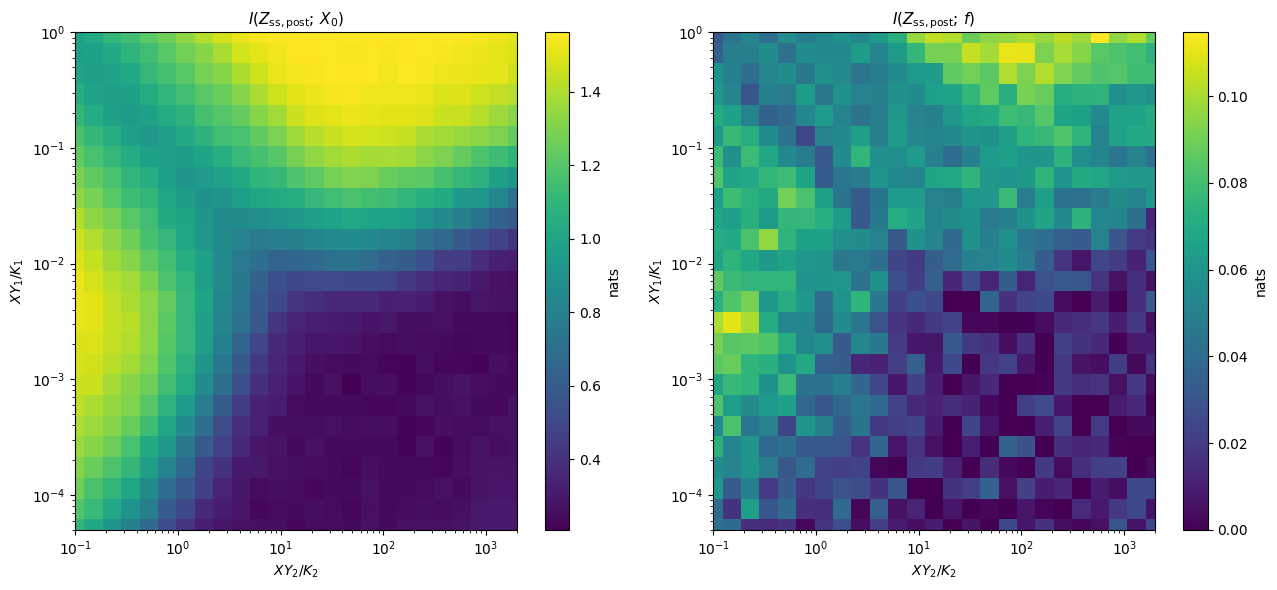

In [12]:
# ============================================================
#  MI(Z_ss_post, X_0)  and  MI(Z_ss_post, f)
#  across the rho1/rho2 grid saved by the Gillespie script.
#
#  Zes[i, j, :] is Z at t_max for grid point (rho1[i], rho2[j]),
#  so pcolormesh(rho2, rho1, data) maps directly — no sorting needed.
# ============================================================
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_selection import mutual_info_regression
from time import perf_counter

def log_edges(centers):
    log_c = np.log10(centers)
    half  = 0.5 * np.diff(log_c)
    return 10.0 ** np.concatenate([
        [log_c[0] - half[0]],
        log_c[:-1] + half,
        [log_c[-1] + half[-1]],
    ])

# ---------------- Load ----------------
d          = np.load('./data/fcd_mi_multi_site16_rho.npz')
rho1_arr   = d['rho1']        # XY1/K1, shape (N_grid,), y-axis
rho2_arr   = d['rho2']        # XY2/K2, shape (N_grid,), x-axis
X0_samples = d['X0_samples']
f_samples  = d['f_samples']
Zes        = d['Zes']         # Z_ss_post, shape (N_grid, N_grid, N_samples)

log_X0 = np.log10(X0_samples)
N1, N2, _ = Zes.shape

# ---------------- Compute MI per pixel ----------------
print("Computing MI(Z_ss_post, X_0) and MI(Z_ss_post, f) ...")
MI_Ze_X0 = np.zeros((N1, N2))
MI_Ze_f  = np.zeros((N1, N2))

t0 = perf_counter()
for i in range(N1):
    if i % max(1, N1 // 4) == 0 or i == N1 - 1:
        print(f"  row {i+1}/{N1} ...")
    for j in range(N2):
        Ze = Zes[i, j].reshape(-1, 1)
        MI_Ze_X0[i, j] = mutual_info_regression(Ze, log_X0,   random_state=0)[0]
        MI_Ze_f [i, j] = mutual_info_regression(Ze, f_samples, random_state=0)[0]

print(f"  done in {perf_counter()-t0:.1f} s")

MI_Ze_X0 = np.maximum(MI_Ze_X0, 0.0)
MI_Ze_f  = np.maximum(MI_Ze_f,  0.0)

# ---------------- Plot ----------------
xe = log_edges(rho2_arr)
ye = log_edges(rho1_arr)

fig, axes = plt.subplots(1, 2, figsize=(13, 6))

# Panel 1: MI(Z_ss_post, X_0)
ax = axes[0]
im = ax.pcolormesh(xe, ye, MI_Ze_X0,
                   vmin=MI_Ze_X0.min(), vmax=MI_Ze_X0.max(),
                   cmap='viridis', shading='auto')
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlim(rho2_arr.min(), rho2_arr.max())
ax.set_ylim(rho1_arr.min(), rho1_arr.max())
ax.set_xlabel(r'$XY_2/K_2$')
ax.set_ylabel(r'$XY_1/K_1$')
ax.set_title(r'$I(Z_{\rm ss,post};\, X_0)$',
             fontsize=11)
fig.colorbar(im, ax=ax, label='nats')

# Panel 2: MI(Z_ss_post, f)
ax = axes[1]
im = ax.pcolormesh(xe, ye, MI_Ze_f,
                   vmin=MI_Ze_f.min(), vmax=MI_Ze_f.max(),
                   cmap='viridis', shading='auto')
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlim(rho2_arr.min(), rho2_arr.max())
ax.set_ylim(rho1_arr.min(), rho1_arr.max())
ax.set_xlabel(r'$XY_2/K_2$')
ax.set_ylabel(r'$XY_1/K_1$')
ax.set_title(r'$I(Z_{\rm ss,post};\, f)$',
             fontsize=11)
fig.colorbar(im, ax=ax, label='nats')

# fig.suptitle(r'Stochastic FCD landscape — $Z_{\rm ss,post}$ mutual information',
#              fontsize=13)
fig.tight_layout()
plt.show()

The next code simulates many trajectories for a fixed set of parameters to characterise the noise. The output peak distribution is plotted along with a log normal fit.

rho1=0.005, rho2=80
K1=1e+03 nM, K2=0.25 nM
k_on1=0.06, k_off1=60, k_on2=60, k_off2=15

20000 trajectories in 127.5 s
Log-normal fit:  mu_log=-0.03465,  sigma_log=0.1211,  median=0.9659,  CV=0.122


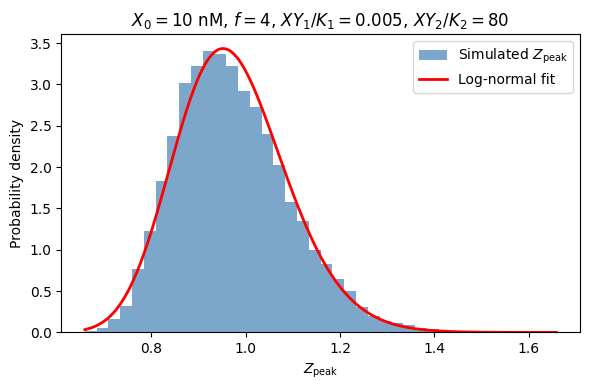

: 

In [ ]:
# ============================================================
#  Z_peak distribution at a user-specified (rho1, rho2) point.
# ============================================================
import numpy as np
import numba as nb
import matplotlib.pyplot as plt
from scipy import stats
from time import perf_counter

# ---- User-specified ----
RHO1    = 0.005     # XY1/K1
RHO2    = 80.0    # XY2/K2
X0      = 10.0    # nM
F       = 4.0      # fold change
N_sims  = 20000

# ---- Fixed model parameters ----
beta1, alpha1 = 0.0025, 0.05
beta2, alpha2 = 0.0001, 0.0005
beta3, alpha3 = 4.1, 4.1e-4
t_max, t_step = 25000.0, 5000.0
N_SITES, M_SITES = 1, 1

K_ON1_MAX, K_OFF1_MAX = 60.0, 60.0
K_ON2_MAX, K_OFF2_MAX = 60.0, 60.0

# ---- Derive rates from rho1, rho2 ----
X0_ref  = np.sqrt(10.0 * 1000.0)   # geometric mean of X0 sweep (= 100 nM)
K1 = beta1 / alpha1 * X0_ref / RHO1
K2 = beta2 / alpha2 * X0_ref / RHO2

k_on1  = min(K_ON1_MAX, K_OFF1_MAX / K1);  k_off1 = K1 * k_on1
k_on2  = min(K_ON2_MAX, K_OFF2_MAX / K2);  k_off2 = K2 * k_on2

print(f"rho1={RHO1:.3g}, rho2={RHO2:.3g}")
print(f"K1={K1:.3g} nM, K2={K2:.3g} nM")
print(f"k_on1={k_on1:.3g}, k_off1={k_off1:.3g}, k_on2={k_on2:.3g}, k_off2={k_off2:.3g}")

# ---- Gillespie kernel ----
@nb.njit(fastmath=True)
def _gillespie(X0, F, k_on1, k_off1, k_on2, k_off2):
    XY1_0 = beta1 / alpha1 * X0
    XY2_0 = beta2 / alpha2 * X0
    p1 = XY1_0 / (k_off1 / k_on1 + XY1_0)
    p2 = XY2_0 / (k_off2 / k_on2 + XY2_0)
    Z  = beta3 / alpha3 * ((1.0 - (1.0 - p1)**N_SITES) * (1.0 - p2**M_SITES))

    i, j, t, Z_peak, base_set = 0, 0, 0.0, 0.0, False

    while t < t_max:
        XY1 = beta1 / alpha1 * (X0 if t < t_step else
              F * X0 + (X0 - F * X0) * np.exp(-alpha1 * (t - t_step)))
        XY2 = beta2 / alpha2 * (X0 if t < t_step else
              F * X0 + (X0 - F * X0) * np.exp(-alpha2 * (t - t_step)))

        r0 = (N_SITES - i) * XY1 * k_on1 if i < N_SITES else 0.0
        r1 = i * k_off1                   if i > 0       else 0.0
        r2 = (M_SITES - j) * XY2 * k_on2 if j < M_SITES else 0.0
        r3 = j * k_off2                   if j > 0       else 0.0

        R      = r0 + r1 + r2 + r3
        dt     = -np.log(np.random.uniform()) / R
        active = (i >= 1) and (j < M_SITES)
        ss     = (beta3 / alpha3) if active else 0.0

        if not base_set and t + dt >= t_step:
            Z_peak   = ss + (Z - ss) * np.exp(-alpha3 * (t_step - t))
            base_set = True

        Z_new = ss + (Z - ss) * np.exp(-alpha3 * dt)
        if base_set and Z_new > Z_peak:
            Z_peak = Z_new
        Z = Z_new
        t += dt

        u = np.random.uniform() * R
        if   u < r0:             i += 1
        elif u < r0 + r1:        i -= 1
        elif u < r0 + r1 + r2:   j += 1
        else:                    j -= 1

    return Z_peak

@nb.njit(parallel=True)
def run_many(N, X0, F, k_on1, k_off1, k_on2, k_off2):
    peaks = np.empty(N)
    for k in nb.prange(N):
        peaks[k] = _gillespie(X0, F, k_on1, k_off1, k_on2, k_off2)
    return peaks

# ---- Run ----
_ = run_many(2, X0, F, k_on1, k_off1, k_on2, k_off2)   # JIT warm-up
t0    = perf_counter()
peaks = run_many(N_sims, X0, F, k_on1, k_off1, k_on2, k_off2)
print(f"\n{N_sims} trajectories in {perf_counter()-t0:.1f} s")

# ---- Log-normal fit & plot ----
# Z_peak is positive and right-skewed, so fit log(Z_peak) with a normal,
# which is equivalent to a log-normal fit on Z_peak itself.
log_peaks = np.log(peaks)
mu_log, sigma_log = log_peaks.mean(), log_peaks.std()
print(f"Log-normal fit:  mu_log={mu_log:.4g},  sigma_log={sigma_log:.4g},  "
      f"median={np.exp(mu_log):.4g},  CV={np.sqrt(np.exp(sigma_log**2)-1):.3f}")

fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(peaks, bins=40, density=True, color='steelblue', alpha=0.7,
        label='Simulated $Z_{\\rm peak}$')
x = np.linspace(peaks.min(), peaks.max(), 400)
ax.plot(x, stats.lognorm.pdf(x, s=sigma_log, scale=np.exp(mu_log)),
        'r-', lw=2,
        # label=rf'Log-normal fit ($\mu_\ell={mu_log:.3g}$, $\sigma_\ell={sigma_log:.3g}$)')
        label=rf'Log-normal fit')
ax.set_xlabel(r'$Z_{\rm peak}$')
ax.set_ylabel('Probability density')
ax.set_title(rf'$X_0={X0:.0f}$ nM, $f={F:.0f}$, '
             rf'$XY_1/K_1={RHO1:.3g}$, $XY_2/K_2={RHO2:.3g}$')
ax.legend()
fig.tight_layout()
fig.savefig('./figures/log-normal-fit.png', dpi=300)
plt.show()

In the following code, the predicted relRMSE is plotted across the ($XY_1/K_1$,$XY_2/K_2$) plane.

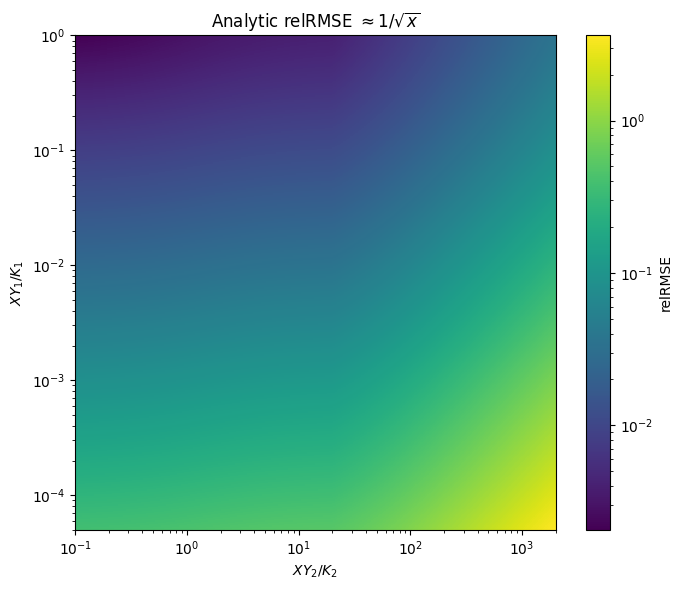

In [37]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

# ---------------- Fixed parameters ----------------
beta1, alpha1 = 0.0025, 0.05
beta2, alpha2 = 0.0001, 0.0005
alpha3 = 4.1e-4

K_ON1_MAX, K_OFF1_MAX = 60.0, 60.0   # nM^-1 min^-1, min^-1
K_ON2_MAX, K_OFF2_MAX = 60.0, 60.0   # nM^-1 min^-1, min^-1

# ================================================================
#  Grid specification — edit these to change the swept region.
# ================================================================
RHO1_LO, RHO1_HI = 5e-5, 1.0     # XY1/K1 range (y-axis)
RHO2_LO, RHO2_HI = 1e-1, 2e3     # XY2/K2 range (x-axis)
N_grid = 400

X0_ref = np.sqrt(10.0 * 1000.0)       # geometric mean of X0 sweep = 100 nM
XY1    = beta1 / alpha1 * X0_ref       # = 5 nM
XY2    = beta2 / alpha2 * X0_ref       # = 20 nM

# ---------------- Grid ----------------
rho1 = np.logspace(np.log10(RHO1_LO), np.log10(RHO1_HI), N_grid)
rho2 = np.logspace(np.log10(RHO2_LO), np.log10(RHO2_HI), N_grid)
RHO1, RHO2 = np.meshgrid(rho1, rho2, indexing='ij')

# ---------------- Stationary occupancies ----------------
p1 = RHO1 / (RHO1 + 1)
p2 = RHO2 / (RHO2 + 1)

# ---------------- Relaxation rates ----------------
# For each site, optimal_rates() gives k_on = min(k_on_max, k_off_max/K).
# This leads to a crossover at rho_i = XY_i * k_on_max / k_off_max:
#   rho_i < crossover: k_off hits cap -> r_i = k_off_max * (rho_i + 1)
#   rho_i > crossover: k_on  hits cap -> r_i = k_on_max * XY_i * (rho_i + 1) / rho_i
rho1_cross = XY1 * K_ON1_MAX / K_OFF1_MAX   # = 5
rho2_cross = XY2 * K_ON2_MAX / K_OFF2_MAX   # = 20

r1 = np.where(RHO1 < rho1_cross,
              K_OFF1_MAX * (RHO1 + 1),
              K_ON1_MAX * XY1 * (RHO1 + 1) / RHO1)

r2 = np.where(RHO2 < rho2_cross,
              K_OFF2_MAX * (RHO2 + 1),
              K_ON2_MAX * XY2 * (RHO2 + 1) / RHO2)

# ---------------- Integrated autocorrelation time ----------------
num     = p1*p2/r2 + (1-p1)*(1-p2)/r1 + (1-p1)*p2/(r1+r2)
den     = 1.0 - p1*(1-p2)
tau_int = num / den

# ---------------- Collapse variable and RelRMSE ----------------
Pa      = p1 * (1 - p2)
x       = Pa / ((1 - Pa) * alpha3 * tau_int)
RelRMSE = 1.0 / np.sqrt(x)

# ---------------- Plot ----------------
fig, ax = plt.subplots(figsize=(7, 6))
im = ax.pcolormesh(rho2, rho1, RelRMSE,
                   norm=LogNorm(vmin=RelRMSE.min(), vmax=RelRMSE.max()),
                   cmap='viridis', shading='auto')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlim(RHO2_LO, RHO2_HI)
ax.set_ylim(RHO1_LO, RHO1_HI)
ax.set_xlabel(r'$XY_2/K_2$')
ax.set_ylabel(r'$XY_1/K_1$')
ax.set_title(r'Analytic relRMSE $\approx 1/\sqrt{x}$')
fig.colorbar(im, ax=ax, label='relRMSE')
# fig.suptitle(rf'$X_{{0,\rm ref}} = {X0_ref:.0f}$ nM')
fig.tight_layout()
fig.savefig('./figures/RMSE_heatmap', dpi=300)
plt.show()

This final code allows for analysing the output distributions from the information theoretic tests performed in one of the previous cells.

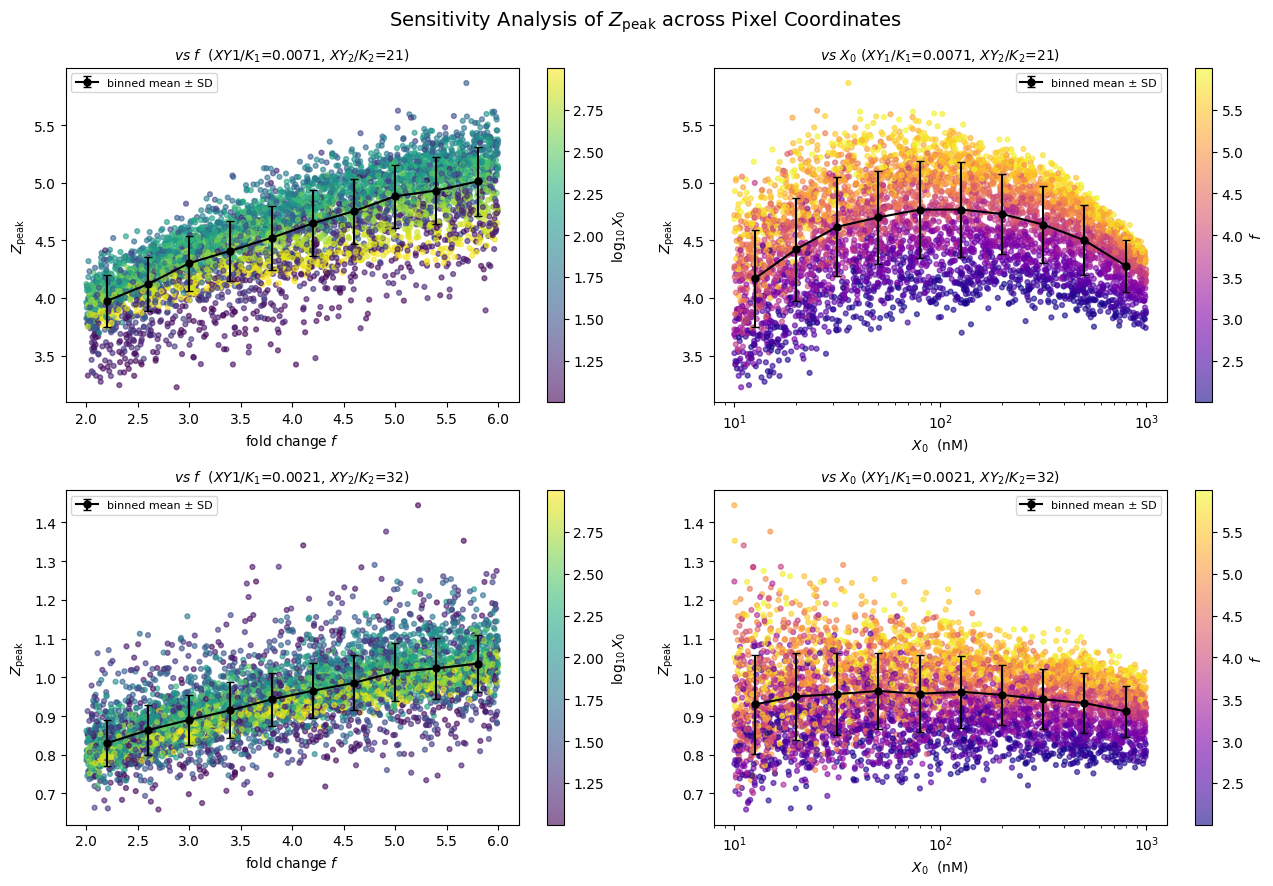

In [19]:
# ============================================================
#  Distribution of Z_peak at a chosen (rho1, rho2) pixel.
#  Loads the rho-space scan saved by the Gillespie script.
# ============================================================
import numpy as np
import matplotlib.pyplot as plt

d = np.load('./data/fcd_mi_multi_site16_rho.npz')
rho1_arr   = d['rho1']        # XY1/K1, shape (N_grid,)
rho2_arr   = d['rho2']        # XY2/K2, shape (N_grid,)
X0_samples = d['X0_samples']
f_samples  = d['f_samples']
Zbs        = d['Zbs']
Zps        = d['Zps']
Zes        = d['Zes']
log_X0     = np.log10(X0_samples)


def _binned_stats(x, y, n_bins=10, log_bins=False):
    """Equal-width (linear or log) binning -> centres, means, stds."""
    if log_bins:
        edges   = np.logspace(np.log10(x.min()), np.log10(x.max()), n_bins + 1)
        centres = np.sqrt(edges[:-1] * edges[1:])
    else:
        edges   = np.linspace(x.min(), x.max(), n_bins + 1)
        centres = 0.5 * (edges[:-1] + edges[1:])
    idx   = np.clip(np.digitize(x, edges) - 1, 0, n_bins - 1)
    means = np.array([y[idx == k].mean() if (idx == k).any() else np.nan
                      for k in range(n_bins)])
    stds  = np.array([y[idx == k].std()  if (idx == k).any() else np.nan
                      for k in range(n_bins)])
    return centres, means, stds


def show_pixel(target_rho1, target_rho2, axes_row):
    """Inspect the Z_peak distribution dependencies at the grid cell closest to
    (target_rho1, target_rho2) on the log-spaced rho grid.
    
    axes_row: an array of 2 matplotlib axes representing a row in the 2x2 grid.
    """
    i = int(np.argmin(np.abs(np.log(rho1_arr) - np.log(target_rho1))))
    j = int(np.argmin(np.abs(np.log(rho2_arr) - np.log(target_rho2))))
    Y = Zps[i, j]

    # ---- 1. Z_peak vs f, coloured by log X0 ----
    ax = axes_row[0]
    sc1 = ax.scatter(f_samples, Y, c=log_X0, cmap='viridis', s=12, alpha=0.6)
    cf, mf, sf = _binned_stats(f_samples, Y, n_bins=10, log_bins=False)
    ax.errorbar(cf, mf, yerr=sf, fmt='k-o', lw=1.5, capsize=3, markersize=5,
                label='binned mean ± SD')
    ax.set_xlabel(r'fold change $f$')
    ax.set_ylabel(r'$Z_{\rm peak}$')
    ax.legend(loc='best', fontsize=8)
    plt.colorbar(sc1, ax=ax, label=r'$\log_{10} X_0$')
    
    # Add coordinates as a subtitle or track via clean titles
    ax.set_title(rf'$vs\ f$  ($XY1/K_1$={rho1_arr[i]:.2g}, $XY_2/K_2$={rho2_arr[j]:.2g})', fontsize=10)

    # ---- 2. Z_peak vs X0 (log axis), coloured by f ----
    ax = axes_row[1]
    sc2 = ax.scatter(X0_samples, Y, c=f_samples, cmap='plasma', s=12, alpha=0.6)
    cx, mx, sx = _binned_stats(X0_samples, Y, n_bins=10, log_bins=True)
    ax.errorbar(cx, mx, yerr=sx, fmt='k-o', lw=1.5, capsize=3, markersize=5,
                label='binned mean ± SD')
    ax.set_xscale('log')
    ax.set_xlabel(r'$X_0$  (nM)')
    ax.set_ylabel(r'$Z_{\rm peak}$')
    ax.legend(loc='best', fontsize=8)
    plt.colorbar(sc2, ax=ax, label=r'$f$')
    ax.set_title(rf'$vs\ X_0$ ($XY_1/K_1$={rho1_arr[i]:.2g}, $XY_2/K_2$={rho2_arr[j]:.2g})', fontsize=10)


# Create the unified 2x2 layout
fig, axs = plt.subplots(2, 2, figsize=(13, 9))

# Populate Row 1 (Pixel 1)
show_pixel(0.006, 20, axes_row=axs[0])

# Populate Row 2 (Pixel 2)
show_pixel(0.002, 30.0, axes_row=axs[1])

fig.suptitle('Sensitivity Analysis of $Z_{\\rm peak}$ across Pixel Coordinates', fontsize=14, y=0.98)
fig.tight_layout()
fig.savefig(f'pixel_dist.png', dpi=300)
plt.show()